In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import subprocess, os
import h5py
import matplotlib.pyplot as plt
from matplotlib.transforms import Affine2D
import h5py, re, tqdm
from collections import Counter
import random
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from scipy.signal import savgol_filter
from sklearn.preprocessing import Normalizer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [17]:
# Mounting dataset from D: to WSL 
WINDOWS_DRIVE = "E:"   
WINDOWS_PATH = r"E:\HSI_Dataset_2\Elements\data"
LINK_NAME     = "data_external"  

# Mount drive if missing
mnt_path = Path(f"/mnt/{WINDOWS_DRIVE[0].lower()}")
#if not mnt_path.exists():
print(f"[INFO] Mounting {WINDOWS_DRIVE} into {mnt_path} ...")
subprocess.run(["sudo", "mkdir", "-p", str(mnt_path)], check=True)
res = subprocess.run(["sudo", "mount", "-t", "drvfs", WINDOWS_DRIVE, str(mnt_path)], capture_output=True, text=True)
if res.returncode != 0:
    raise RuntimeError(f"Failed to mount {WINDOWS_DRIVE}: {res.stderr}")

# Verify dataset path 
dataset_path = Path(str(WINDOWS_PATH).replace("\\", "/").replace(":", "").replace("E", "/mnt/e", 1))
if not dataset_path.exists():
    print(f"[WARN] Dataset not found at {dataset_path}. Let's check what's under /mnt/e:")
    os.system("ls -la /mnt/d")
    raise FileNotFoundError("Fix dataset path above and rerun.")
print(f"[OK] Found dataset: {dataset_path}")

# Create symlink inside project
proj_root = Path.cwd()
link_path = proj_root / LINK_NAME
if link_path.exists() or link_path.is_symlink():
    print(f"[INFO] Removing old link {link_path}")
    link_path.unlink()
link_path.symlink_to(dataset_path, target_is_directory=True)
print(f"[OK] Linked {link_path} -> {dataset_path}")

# Show a few sample files for confirmation
import itertools
exts = {".hdf5", ".h5", ".hdr", ".tif", ".tiff"}
found = list(itertools.islice((p for p in link_path.rglob("*") if p.suffix.lower() in exts), 10))
if found:
    print("Sample files:")
    for f in found: print("  ", f.relative_to(link_path))
else:
    print("No .hdf5/.h5/.hdr/.tif files found yet — check deeper folders.")

[INFO] Mounting E: into /mnt/e ...
[OK] Found dataset: /mnt/e/HSI_Dataset_2/Elements/data
[INFO] Removing old link /home/isaacmuscat/Grain-Variety-Classification/data_external
[OK] Linked /home/isaacmuscat/Grain-Variety-Classification/data_external -> /mnt/e/HSI_Dataset_2/Elements/data
Sample files:
   raw/calibration/FX10/calibration_1705a_0.hdf5
   raw/calibration/FX10/calibration_1705a_1.hdf5
   raw/calibration/FX10/calibration_1705a_2.hdf5
   raw/calibration/FX10/calibration_1705a_3.hdf5
   raw/calibration/FX10/calibration_1705_0.hdf5
   raw/calibration/FX10/calibration_1705_1.hdf5
   raw/calibration/FX10/calibration_1705_2.hdf5
   raw/calibration/FX10/calibration_1705_3.hdf5
   raw/calibration/Snapshot/processed/calibration_1705a_0/image_0000000003.hdr
   raw/calibration/Snapshot/processed/calibration_1705a_1/image_0000000000.hdr


In [18]:
ROOT = Path("data_external")

LR_ROOT = ROOT / "raw" / "Snapshot" / "unprocessed" 

OUTDIR = ROOT / "processed" / "quickrun"
OUTDIR.mkdir(parents=True, exist_ok=True)

print("ROOT:         ", ROOT.resolve())
print("LR train path:", LR_ROOT.resolve())
print("OUTDIR:       ", OUTDIR.resolve())

ROOT:          /mnt/e/HSI_Dataset_2/Elements/data
LR train path: /mnt/e/HSI_Dataset_2/Elements/data/raw/Snapshot/unprocessed
OUTDIR:        /mnt/e/HSI_Dataset_2/Elements/data/processed/quickrun


In [19]:
# --- Find all Snapshot RAW files via the folder structure ---
rows = []

case_regex = re.compile(r"^([a-zA-Z]+)_(s|m|l)_unprocessed$")

for case_dir in sorted(LR_ROOT.iterdir()):
    if not case_dir.is_dir():
        continue

    m = case_regex.match(case_dir.name)
    if m is None:
        continue

    variety, size = m.group(1), m.group(2)

    for subdir in sorted(case_dir.iterdir()):
        if not subdir.is_dir() or subdir.name == "context":
            continue

        if not subdir.name.startswith(f"{variety}_{size}"):
            continue

        if not subdir.name[-1].isdigit():
            continue
        rep = int(subdir.name[-1])

        raw_candidates = list(subdir.glob("*.RAW")) + list(subdir.glob("*.raw"))
        if len(raw_candidates) == 0:
            continue

        raw_path = raw_candidates[0]
        sample_name = f"{variety}_{size}{rep}"

        rows.append({
            "filepath_snapshot": raw_path,
            "variety": variety,
            "size": size,
            "rep": rep,
            "sample_folder": subdir.name,
            "sample_name": sample_name,
            "case_name": case_dir.name,
        })

lr_df = pd.DataFrame(rows)
print("Number of Snapshot RAW training files:", len(lr_df))
lr_df.head()

Number of Snapshot RAW training files: 180


,filepath_snapshot,variety,size,rep,sample_folder,sample_name,case_name
0,data_external/raw/Snapshot/unprocessed/barley_...,barley,l,0,barley_l0,barley_l0,barley_l_unprocessed
1,data_external/raw/Snapshot/unprocessed/barley_...,barley,l,1,barley_l1,barley_l1,barley_l_unprocessed
2,data_external/raw/Snapshot/unprocessed/barley_...,barley,l,2,barley_l2,barley_l2,barley_l_unprocessed
3,data_external/raw/Snapshot/unprocessed/barley_...,barley,l,3,barley_l3,barley_l3,barley_l_unprocessed
4,data_external/raw/Snapshot/unprocessed/barley_...,barley,l,4,barley_l4,barley_l4,barley_l_unprocessed


In [20]:
# --- Validate Snapshot RAW training files ---
all_lr_files = list(lr_df["filepath_snapshot"])
print("Total Snapshot RAW files found:", len(all_lr_files))

def resolve_valid_snapshot(path: Path) -> Path | None:
    path = Path(path)
    try:
        if not path.exists():
            return None
        if path.stat().st_size == 0:
            return None
        return path
    except Exception:
        return None

lr_df["resolved_path"] = lr_df["filepath_snapshot"].apply(resolve_valid_snapshot)

df_valid = lr_df[lr_df["resolved_path"].notna()].copy()
df_invalid = lr_df[lr_df["resolved_path"].isna()].copy()

print("Valid Snapshot RAW files:", len(df_valid))
print("Invalid Snapshot RAW files:", len(df_invalid))

if not df_invalid.empty:
    print(df_invalid[["sample_name", "filepath_snapshot"]].head())

Total Snapshot RAW files found: 180
Valid Snapshot RAW files: 180
Invalid Snapshot RAW files: 0


In [ ]:
# --- Split files into train and test files ---
varieties = ["barley", "buckwheat", "corn", "flax", "flaxb", "millet", "pumpkin", "rye", "spelt", "sunflower", "wheatgrass"]

mask_test = df_valid["sample_name"].str.contains(r"_[sml]4$", regex=True, na=False)

test_files = df_valid[mask_test]
all_train_files = df_valid[~mask_test]

print("Total number of train files:", len(all_train_files))
print("Total number of test files:", len(test_files))

# --- Remove MIX class from the train and test sets ---
all_train_files = all_train_files[all_train_files["variety"] != "mix"].reset_index(drop=True)
test_files  = test_files[test_files["variety"] != "mix"].reset_index(drop=True)

print("Remaining train classes:", sorted(all_train_files["variety"].unique()))
print("Remaining test classes: ", sorted(test_files["variety"].unique()))

print("Train size:", len(all_train_files))
print("Test size: ", len(test_files))

# --- Split current training files into train and validation at Image level - for proper class balance ---
# One validation image per variety; rest stay in train.
val_rows = []
train_rows = []

for var in sorted(all_train_files["variety"].unique()):
    sub = all_train_files[all_train_files["variety"] == var].sort_values("sample_name").reset_index(drop=True)

    # use the last available image of each class as validation
    if len(sub) < 2:
        raise ValueError(f"Not enough training images for variety '{var}' to create validation split.")

    val_rows.append(sub.iloc[-1])
    train_rows.append(sub.iloc[:-1])

val_files = pd.DataFrame(val_rows).reset_index(drop=True)
train_files = pd.concat(train_rows, axis=0).reset_index(drop=True)

print("train_core_files:", len(train_files))
print("val_files:", len(val_files))
print("test_files:", len(test_files))

print("\nValidation samples:")
print(sorted(val_files["sample_name"].tolist()))


Total number of train files: 144
Total number of test files: 36
Remaining train classes: ['barley', 'buckwheat', 'corn', 'flax', 'flaxb', 'millet', 'pumpkin', 'rye', 'spelt', 'sunflower', 'wheatgrass']
Remaining test classes:  ['barley', 'buckwheat', 'corn', 'flax', 'flaxb', 'millet', 'pumpkin', 'rye', 'spelt', 'sunflower', 'wheatgrass']
Train size: 132
Test size:  33
train_core_files: 121
val_files: 11
test_files: 33

Validation samples:
['barley_s3', 'buckwheat_s3', 'corn_s3', 'flax_s3', 'flaxb_s3', 'millet_s3', 'pumpkin_s3', 'rye_s3', 'spelt_s3', 'sunflower_s3', 'wheatgrass_s3']


In [22]:
# --- Defining a few new columns for the HR train files ---
train_files.loc[:, 'variety'] = train_files['sample_name'].str.split("_").str[0]
train_files.loc[:, 'batch']   = train_files['sample_name'].str.split("_").str[-1]

train_files.loc[:, 'size'] = train_files['batch'].str[0]          
train_files.loc[:, 'rep']  = train_files['batch'].str[1:].astype(int)   

# PRE-PROCESSING

In [23]:
import cv2
import numpy as np

def _bandwise_median_denoise(cube, ksize=3):
    """
    Removes salt-and-pepper noise band by band.
    ksize must be odd: 3 is a good starting point.
    """
    if ksize is None or ksize < 3:
        return cube.astype(np.float32)

    out = np.empty_like(cube, dtype=np.float32)
    for b in range(cube.shape[-1]):
        band = np.asarray(cube[:, :, b], dtype=np.float32)
        out[:, :, b] = cv2.medianBlur(band, ksize)
    return out.astype(np.float32)


def _illumination_flatfield_correction(cube, sigma=15, eps=1e-6):
    """
    Removes smooth large-scale illumination gradients per band
    while preserving local structure.
    """
    if sigma is None or sigma <= 0:
        return cube.astype(np.float32)

    out = np.empty_like(cube, dtype=np.float32)

    for b in range(cube.shape[-1]):
        band = np.asarray(cube[:, :, b], dtype=np.float32)

        smooth = cv2.GaussianBlur(band, (0, 0), sigmaX=sigma, sigmaY=sigma)

        finite = np.isfinite(smooth)
        if finite.any():
            target_level = np.median(smooth[finite])
        else:
            target_level = 1.0

        corrected = band / np.maximum(smooth, eps) * target_level
        out[:, :, b] = corrected

    return out.astype(np.float32)


def _snv_per_pixel(cube, eps=1e-6):
    """
    Standard Normal Variate across the spectral axis for each pixel.
    This helps when absolute brightness differs across pixels/images.
    """
    cube = np.asarray(cube, dtype=np.float32)

    mean_spec = np.mean(cube, axis=2, keepdims=True)
    std_spec = np.std(cube, axis=2, keepdims=True)

    return ((cube - mean_spec) / np.maximum(std_spec, eps)).astype(np.float32)


def _safe_clip_cube(cube, lo=0.0, hi=1.0):
    cube = np.nan_to_num(cube, nan=0.0, posinf=hi, neginf=lo).astype(np.float32)
    return np.clip(cube, lo, hi).astype(np.float32)

In [24]:
# --- Snapshot preprocessing: metadata-driven native reconstruction + crop ---
import math
import re
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import numpy as np


# Helper functions
def _parse_numeric(text, cast=float, default=None):
    try:
        return cast(text)
    except Exception:
        return default


def _read_xml_root(xml_path):
    xml_path = Path(xml_path)
    return ET.parse(xml_path).getroot()


def _find_dataset_root(raw_path):
    raw_path = Path(raw_path).resolve()

    if (raw_path.parent.parent / "context").exists():
        return raw_path.parent.parent

    for parent in raw_path.parents:
        if (parent / "context").exists():
            return parent

    raise FileNotFoundError(f"Could not find dataset root with a context/ folder for {raw_path}")


def find_context_dir(raw_path):
    return _find_dataset_root(raw_path) / "context"


def find_reference_files(raw_path):
    context_dir = find_context_dir(raw_path)

    return {
        "context_dir": context_dir,
        "context_xml": context_dir / "context_description.xml",
        "calibration_xmls": sorted((context_dir / "calibration_file").glob("*.xml")),
        "dark_raws": sorted((context_dir / "dark_references").glob("*.raw")),
        "white_raws": sorted((context_dir / "white_reference").glob("*.raw")),
        "optical_xmls": sorted((context_dir / "optical_setup").glob("*.xml")),
    }


# Metadata-driven RAW reading
def _extract_frame_metadata_from_xml(xml_path):
    if xml_path is None or not Path(xml_path).exists():
        return None

    root = _read_xml_root(xml_path)

    data_format = None
    for elem in root.iter():
        tag = elem.tag.split("}")[-1].lower()
        if tag == "data_format":
            data_format = elem
            break

    if data_format is None:
        return None

    nr_cols = _parse_numeric(data_format.attrib.get("nr_cols"), int)
    nr_rows = _parse_numeric(data_format.attrib.get("nr_rows"), int)
    byte_depth = _parse_numeric(data_format.attrib.get("byte_depth"), int)
    data_type = data_format.attrib.get("data_type", "").strip().lower()

    return {
        "nr_cols": nr_cols,
        "nr_rows": nr_rows,
        "byte_depth": byte_depth,
        "data_type": data_type,
    }


def _dtype_from_metadata(meta):
    if meta is None:
        return None

    dt = meta["data_type"]
    bd = meta["byte_depth"]

    if dt == "float" and bd == 4:
        return np.float32
    if dt == "float" and bd == 8:
        return np.float64
    if dt in ("unsigned int", "uint", "uint16") and bd == 2:
        return np.uint16
    if dt in ("unsigned int", "uint", "uint32") and bd == 4:
        return np.uint32
    if dt in ("int", "signed int") and bd == 2:
        return np.int16
    if dt in ("int", "signed int") and bd == 4:
        return np.int32

    return None


def infer_snapshot_shape(raw_path):
    raw_path = Path(raw_path)

    image_xml = raw_path.with_suffix(raw_path.suffix + ".xml")
    acq_xml = raw_path.parent / "acquisition_description.xml"
    ctx_xml = find_context_dir(raw_path) / "context_description.xml"

    for xml_path in [image_xml, acq_xml, ctx_xml]:
        if xml_path.exists():
            meta = _extract_frame_metadata_from_xml(xml_path)
            if meta and meta["nr_rows"] and meta["nr_cols"]:
                return meta["nr_rows"], meta["nr_cols"]

    raise ValueError(f"Could not infer shape for {raw_path}")


def infer_snapshot_dtype(raw_path):
    raw_path = Path(raw_path)

    image_xml = raw_path.with_suffix(raw_path.suffix + ".xml")
    acq_xml = raw_path.parent / "acquisition_description.xml"
    ctx_xml = find_context_dir(raw_path) / "context_description.xml"

    for xml_path in [image_xml, acq_xml, ctx_xml]:
        if xml_path.exists():
            meta = _extract_frame_metadata_from_xml(xml_path)
            dtype = _dtype_from_metadata(meta)
            if dtype is not None:
                return dtype

    raise ValueError(f"Could not infer dtype for {raw_path}")


def _read_raw_frame(raw_path):
    raw_path = Path(raw_path)
    H, W = infer_snapshot_shape(raw_path)
    dtype = infer_snapshot_dtype(raw_path)

    arr = np.fromfile(raw_path, dtype=dtype)
    expected = H * W
    if arr.size != expected:
        raise ValueError(
            f"Raw size mismatch for {raw_path.name}: expected {expected} values for shape {(H, W)} "
            f"with dtype {dtype}, got {arr.size}"
        )

    return arr.reshape(H, W).astype(np.float32)


# Reference handling
def _extract_integration_time_ms_from_image_xml(raw_path):
    raw_xml = Path(raw_path).with_suffix(Path(raw_path).suffix + ".xml")
    if not raw_xml.exists():
        return None

    root = _read_xml_root(raw_xml)

    for elem in root.iter():
        tag = elem.tag.split("}")[-1].lower()
        if tag == "data_info":
            val = elem.attrib.get("integration_time_ms")
            if val is not None:
                return _parse_numeric(val, float)

    return None


def _extract_time_from_dark_filename(path):
    m = re.search(r"dark_reference_([0-9.]+)\.raw$", Path(path).name)
    if m:
        return _parse_numeric(m.group(1), float)
    return None


def _load_best_dark_reference(raw_path):
    ref_info = find_reference_files(raw_path)
    dark_candidates = ref_info["dark_raws"]
    if not dark_candidates:
        return None

    target_ms = _extract_integration_time_ms_from_image_xml(raw_path)

    if target_ms is None:
        return _read_raw_frame(dark_candidates[0])

    scored = []
    for p in dark_candidates:
        t = _extract_time_from_dark_filename(p)
        if t is not None:
            scored.append((abs(t - target_ms), p))

    if scored:
        scored.sort(key=lambda x: x[0])
        return _read_raw_frame(scored[0][1])

    return _read_raw_frame(dark_candidates[0])


def _load_white_reference(raw_path):
    ref_info = find_reference_files(raw_path)
    white_candidates = ref_info["white_raws"]
    if not white_candidates:
        return None
    return _read_raw_frame(white_candidates[0])


# Calibration info
def _read_calibration_info(raw_path):
    ref_info = find_reference_files(raw_path)
    if not ref_info["calibration_xmls"]:
        return None

    calib_xml = ref_info["calibration_xmls"][0]
    root = _read_xml_root(calib_xml)

    bands = []
    for band in root.findall(".//band"):
        idx = int(band.attrib["index"])
        selected = band.attrib.get("selected", "true").lower() == "true"
        wl_text = band.findtext(".//wavelength_nm")
        wavelength_nm = _parse_numeric(wl_text, float)
        bands.append({
            "index": idx,
            "selected": selected,
            "wavelength_nm": wavelength_nm
        })

    bands = sorted(bands, key=lambda x: x["index"])
    return bands


# Native mosaic -> cube
def _mosaic_to_25planes(mosaic):
    """
    Converts a 5x5 snapshot mosaic to 25 planes in raster order
    1085 x 2045 input -> 217 x 409 x 25.
    """
    planes = []
    for r in range(5):
        for c in range(5):
            planes.append(mosaic[r::5, c::5])
    cube25 = np.stack(planes, axis=-1)
    return cube25


def reconstruct_snapshot_raw_to_native_cube(
    raw_path,
    apply_reference_correction=True,
    sort_bands_by_wavelength=True,
    return_wavelengths=False
):
    """
    Metadata-driven native reconstruction.
    """
    raw_path = Path(raw_path)

    mosaic = _read_raw_frame(raw_path)

    if apply_reference_correction:
        dark = _load_best_dark_reference(raw_path)
        white = _load_white_reference(raw_path)

        if dark is not None:
            mosaic = mosaic - dark

        if dark is not None and white is not None:
            denom = (white - dark).astype(np.float32)
            denom[denom <= 0] = np.nan
            mosaic = mosaic / denom

        mosaic = np.nan_to_num(mosaic, nan=0.0, posinf=0.0, neginf=0.0)

    cube25 = _mosaic_to_25planes(mosaic)

    calib = _read_calibration_info(raw_path)
    if calib is None or len(calib) != 25:
        raise ValueError(f"Calibration XML missing or invalid for {raw_path}")

    selected_idx = [b["index"] for b in calib if b["selected"]]
    wavelengths = [b["wavelength_nm"] for b in calib if b["selected"]]

    if len(selected_idx) != 24:
        raise ValueError(f"Expected 24 selected bands from calibration, got {len(selected_idx)}")

    cube24 = cube25[:, :, selected_idx]

    if sort_bands_by_wavelength:
        order = np.argsort(wavelengths)
        cube24 = cube24[:, :, order]
        wavelengths = [wavelengths[i] for i in order]

    cube24 = np.nan_to_num(cube24, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    if return_wavelengths:
        return cube24, np.array(wavelengths, dtype=np.float32)

    return cube24


# Preprocessing layer
def _center_crop_cube(cube, target_shape=(215, 407)):
    """
    Crop cube appropriately by removing one pixel from each side for expected shape
    """
    cube = np.asarray(cube, dtype=np.float32)
    H, W, B = cube.shape
    th, tw = target_shape

    if H < th or W < tw:
        raise ValueError(f"Cube too small for target crop: {cube.shape} vs {target_shape}")

    top = (H - th) // 2
    left = (W - tw) // 2
    return cube[top:top + th, left:left + tw, :]

def preprocess_snapshot_cube(
    raw_path,
    apply_reference_correction=True,
    crop_to_thesis_shape=True,
    median_ksize=3,
    illumination_sigma=15,
    apply_snv=False,
    clip_reflectance=True,
    return_wavelengths=False
):
    """
    Full preprocessing from RAW to final modeling cube
    1. native metadata-driven reconstruction
    2. crop
    3. median denoising
    4. illumination correction
    5. clip reflectance 
    """

    if return_wavelengths:
        cube, wlens = reconstruct_snapshot_raw_to_native_cube(
            raw_path,
            apply_reference_correction=apply_reference_correction,
            return_wavelengths=True
        )
    else:
        cube = reconstruct_snapshot_raw_to_native_cube(
            raw_path,
            apply_reference_correction=apply_reference_correction,
            return_wavelengths=False
        )
        wlens = None

    # Native should be around 217 x 409 x 24
    if crop_to_thesis_shape:
        cube = _center_crop_cube(cube, target_shape=(215, 407))

    # Remove speckle noise
    cube = _bandwise_median_denoise(cube, ksize=median_ksize)

    # Remove broad illumination gradients
    cube = _illumination_flatfield_correction(cube, sigma=illumination_sigma)

    # Clean output for modeling
    if apply_snv:
        cube = np.nan_to_num(cube, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        cube = _snv_per_pixel(cube)
    else:
        if clip_reflectance:
            cube = _safe_clip_cube(cube, lo=0.0, hi=1.0)
        else:
            cube = np.nan_to_num(cube, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    if return_wavelengths:
        return cube.astype(np.float32), wlens

    return cube.astype(np.float32)

Loaded Snapshot RAW file:
data_external/raw/Snapshot/unprocessed/barley_l_unprocessed/barley_l0/image_0000000000.raw
Native cube shape: (217, 409, 24)
Final preprocessed cube shape: (215, 407, 24)
Wavelengths: [669.56 687.53 700.95 712.38 728.75 739.85 752.87 767.73 780.94 788.24
 803.91 814.08 826.89 842.06 852.77 863.72 877.57 889.22 897.96 912.48
 920.48 929.49 939.62 949.38]
Cube stats: min=0.1685, max=1.0000, mean=0.6980, std=0.0782
Final cube shape used in modeling: (215, 407, 24)


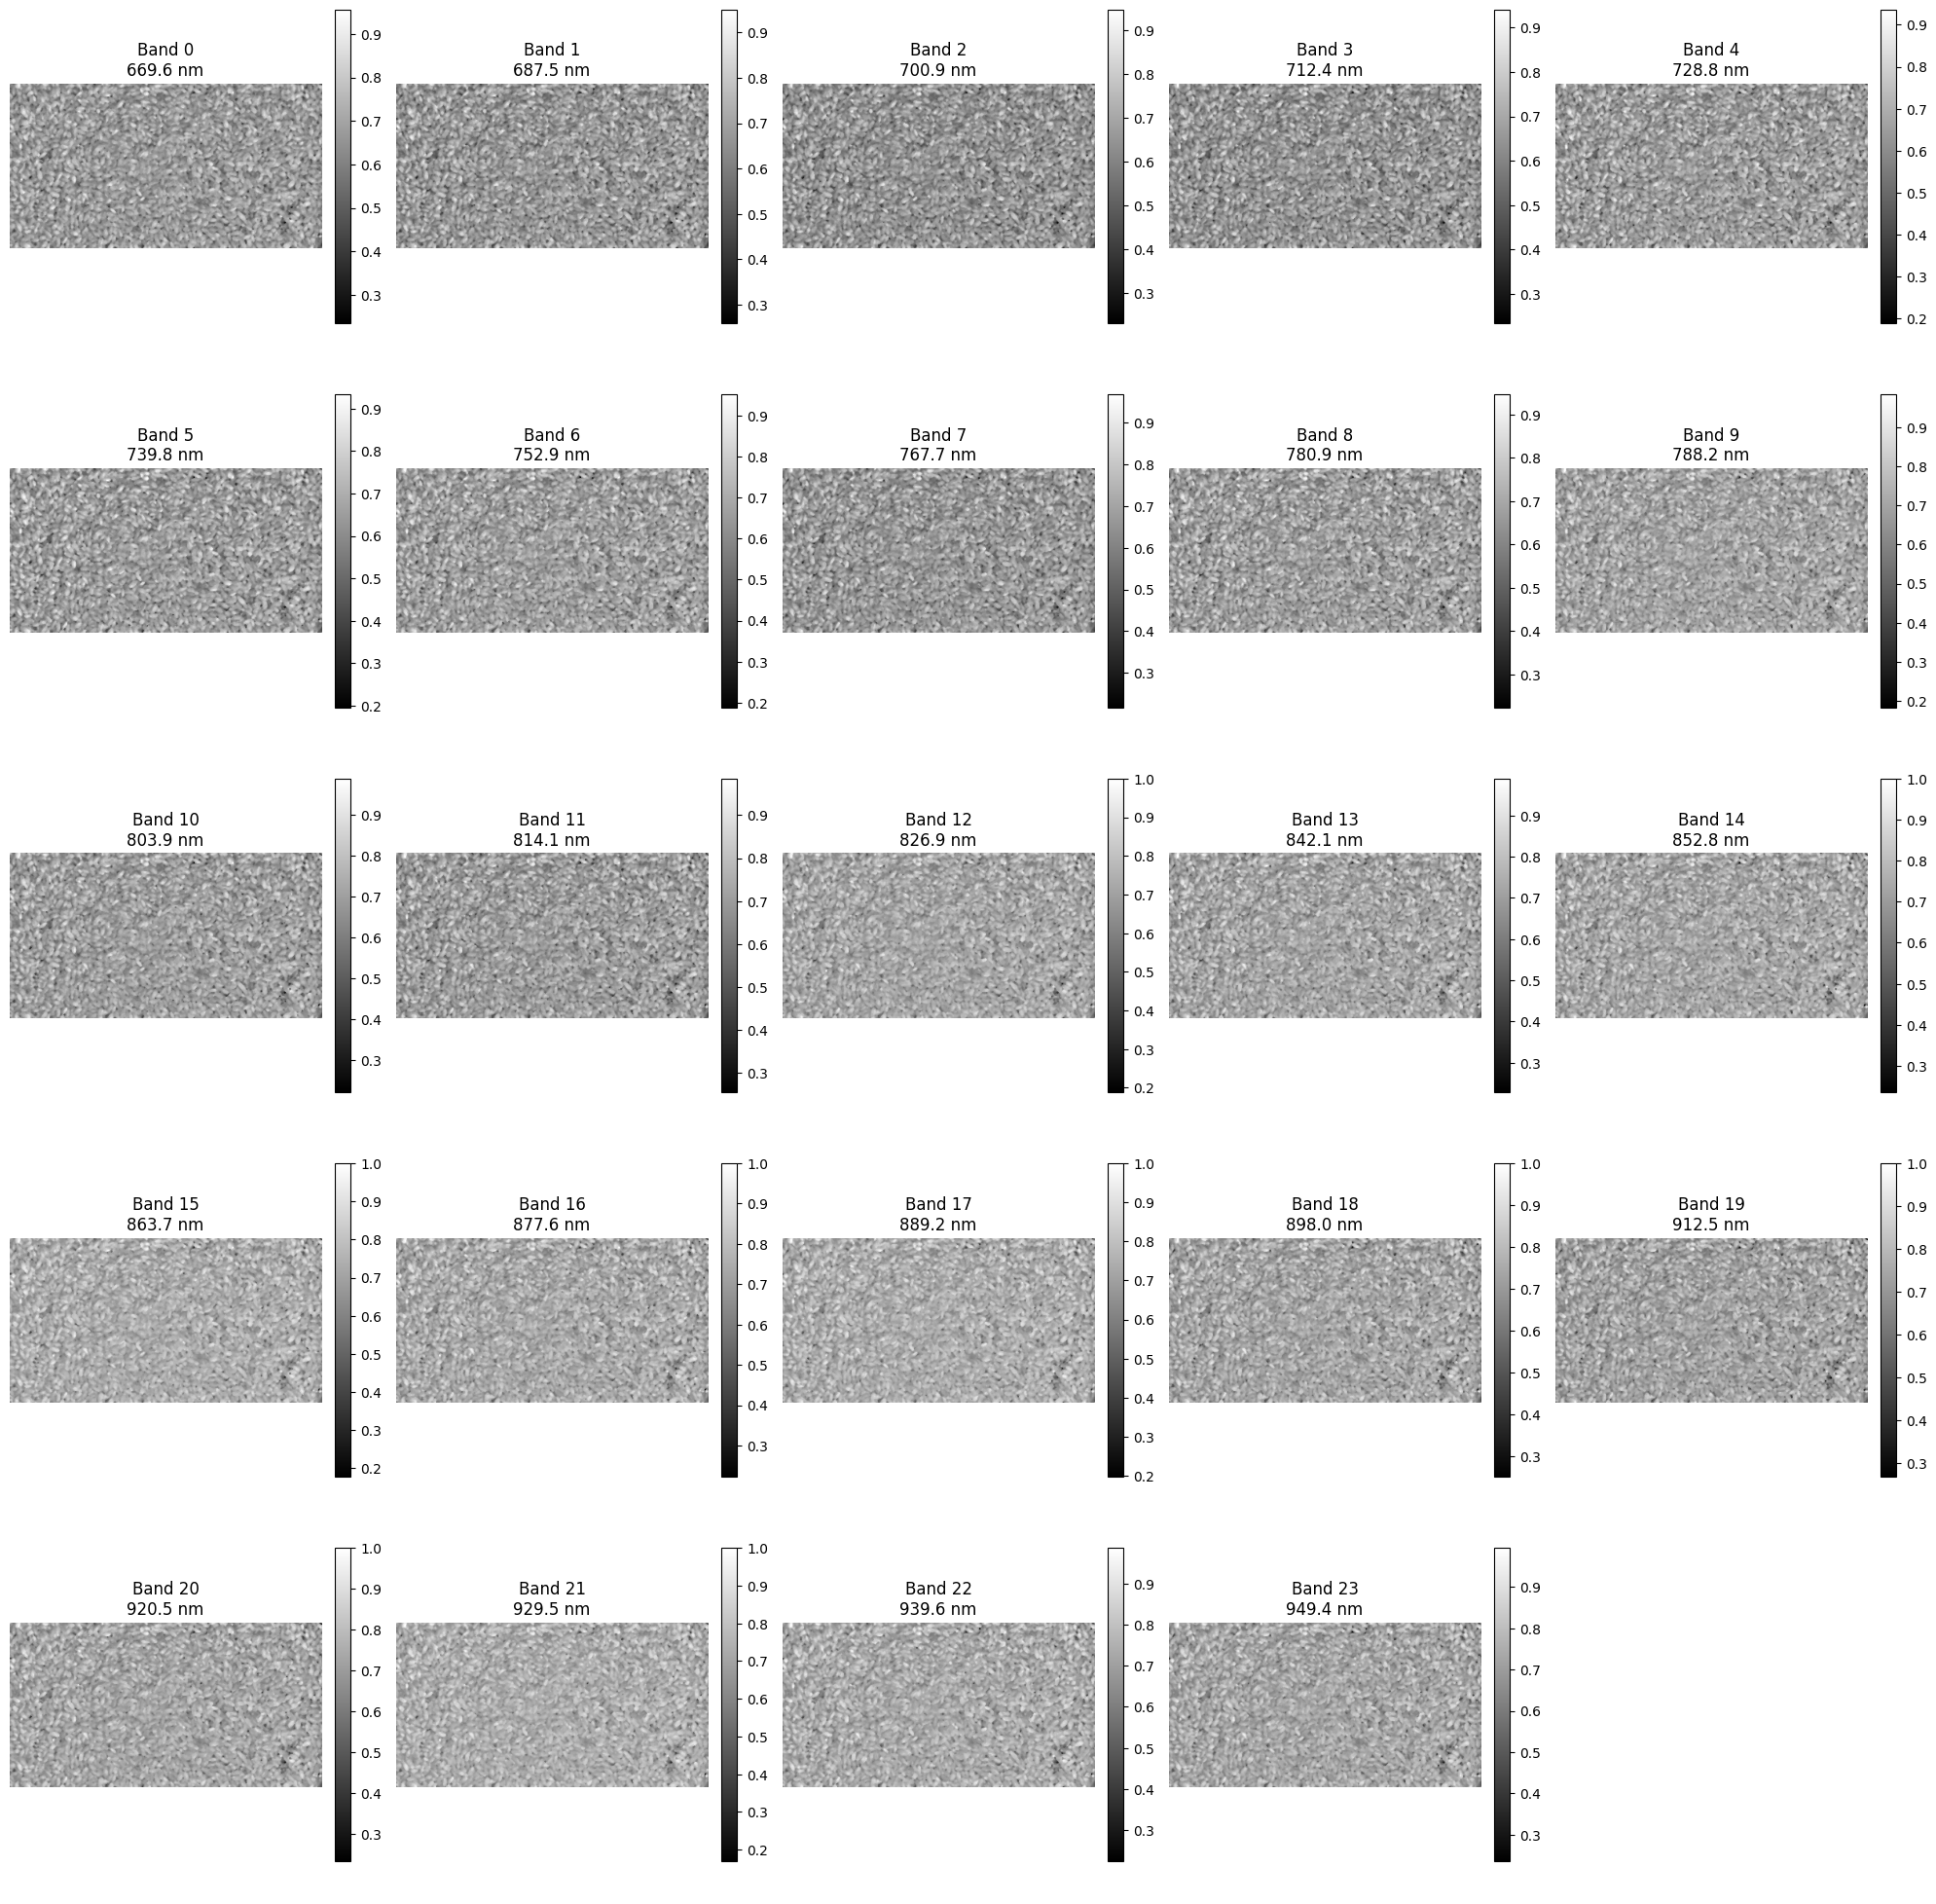

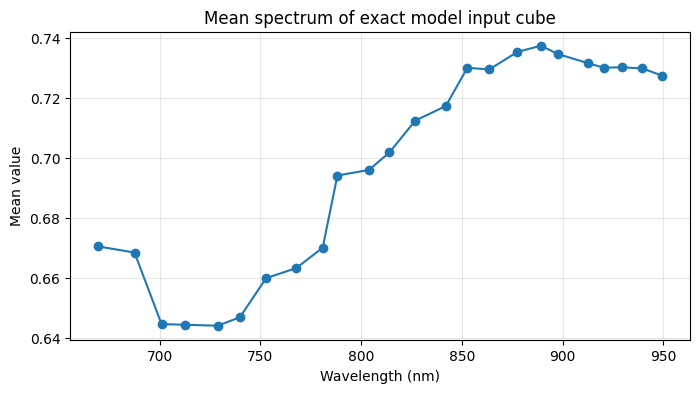

Global cube statistics:
  min  : 0.16848745942115784
  max  : 1.0
  mean : 0.697982132434845
  std  : 0.07817646861076355

Per-band statistics:
Band  0 ( 669.56 nm): min=0.2352, max=0.9565, mean=0.6706, std=0.0714
Band  1 ( 687.53 nm): min=0.2599, max=0.9506, mean=0.6685, std=0.0719
Band  2 ( 700.95 nm): min=0.2318, max=0.9479, mean=0.6447, std=0.0740
Band  3 ( 712.38 nm): min=0.2344, max=0.9410, mean=0.6445, std=0.0739
Band  4 ( 728.75 nm): min=0.1895, max=0.9367, mean=0.6442, std=0.0771
Band  5 ( 739.85 nm): min=0.1950, max=0.9347, mean=0.6470, std=0.0766
Band  6 ( 752.87 nm): min=0.1876, max=0.9528, mean=0.6600, std=0.0757
Band  7 ( 767.73 nm): min=0.2168, max=0.9685, mean=0.6633, std=0.0750
Band  8 ( 780.94 nm): min=0.2228, max=0.9474, mean=0.6702, std=0.0737
Band  9 ( 788.24 nm): min=0.1825, max=0.9852, mean=0.6942, std=0.0721
Band 10 ( 803.91 nm): min=0.2222, max=0.9875, mean=0.6961, std=0.0719
Band 11 ( 814.08 nm): min=0.2551, max=0.9851, mean=0.7019, std=0.0706
Band 12 ( 826.89

In [25]:
# --- Load and Visualize snapshot cube ---
import matplotlib.pyplot as plt

def load_snapshot_cube(
    path,
    verbose=False,
    apply_reference_correction=True,
    median_ksize=3,
    illumination_sigma=15,
    apply_snv=False
):
    path = Path(path)

    cube, wlens = preprocess_snapshot_cube(
        path,
        apply_reference_correction=apply_reference_correction,
        crop_to_thesis_shape=True,
        median_ksize=median_ksize,
        illumination_sigma=illumination_sigma,
        apply_snv=apply_snv,
        clip_reflectance=not apply_snv,
        return_wavelengths=True
    )

    if verbose:
        native_cube, native_wlens = reconstruct_snapshot_raw_to_native_cube(
            path,
            apply_reference_correction=apply_reference_correction,
            return_wavelengths=True
        )
        print(f"Loaded Snapshot RAW file:\n{path}")
        print("Native cube shape:", native_cube.shape)
        print("Final preprocessed cube shape:", cube.shape)
        print("Wavelengths:", np.round(wlens, 2))
        print("Cube stats:",
              f"min={np.nanmin(cube):.4f}, max={np.nanmax(cube):.4f},",
              f"mean={np.nanmean(cube):.4f}, std={np.nanstd(cube):.4f}")

    return cube.astype(np.float32), np.asarray(wlens, dtype=np.float32)


def visualize_cube(filepath_snapshot, n_bands=24, random_seed=42, show_all=False):
    cube, wlens = load_snapshot_cube(filepath_snapshot, verbose=True)

    cube = np.asarray(cube, dtype=np.float32)

    if cube.ndim != 3:
        raise ValueError(f"Expected 3D cube, got shape {cube.shape}")

    H, W, B = cube.shape
    print("Final cube shape used in modeling:", cube.shape)

    # Choose bands - default is to go with all bands
    if show_all:
        channels = np.arange(B)
    else:
        n_show = min(n_bands, B)
        rng = random.Random(random_seed)
        channels = sorted(rng.sample(range(B), n_show))

    n_show = len(channels)
    ncols = 5
    nrows = int(np.ceil(n_show / ncols))

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 4 * nrows))
    axs = np.array(axs).reshape(-1)

    for i, channel in enumerate(channels):
        band_img = cube[:, :, channel]

        im = axs[i].imshow(band_img, cmap="gray")

        if wlens is not None and len(wlens) == B:
            axs[i].set_title(f"Band {channel}\n{wlens[channel]:.1f} nm")
        else:
            axs[i].set_title(f"Band {channel}")

        axs[i].axis("off")
        fig.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)

    for j in range(n_show, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

    # Mean spectrum of model input
    X = cube.reshape(-1, B)
    finite_mask = np.isfinite(X).all(axis=1)
    X = X[finite_mask]

    if X.shape[0] > 0:
        mean_spectrum = X.mean(axis=0)

        plt.figure(figsize=(8, 4))
        if wlens is not None and len(wlens) == B:
            plt.plot(wlens, mean_spectrum, marker="o")
            plt.xlabel("Wavelength (nm)")
        else:
            plt.plot(np.arange(B), mean_spectrum, marker="o")
            plt.xlabel("Band index")

        plt.ylabel("Mean value")
        plt.title("Mean spectrum of exact model input cube")
        plt.grid(True, alpha=0.3)
        plt.show()

    # Some useful numeric diagnostics
    print("Global cube statistics:")
    print("  min  :", float(np.nanmin(cube)))
    print("  max  :", float(np.nanmax(cube)))
    print("  mean :", float(np.nanmean(cube)))
    print("  std  :", float(np.nanstd(cube)))

    print("\nPer-band statistics:")
    for b in range(B):
        band = cube[:, :, b]
        if wlens is not None and len(wlens) == B:
            print(
                f"Band {b:2d} ({wlens[b]:7.2f} nm): "
                f"min={np.nanmin(band):.4f}, max={np.nanmax(band):.4f}, "
                f"mean={np.nanmean(band):.4f}, std={np.nanstd(band):.4f}"
            )
        else:
            print(
                f"Band {b:2d}: "
                f"min={np.nanmin(band):.4f}, max={np.nanmax(band):.4f}, "
                f"mean={np.nanmean(band):.4f}, std={np.nanstd(band):.4f}"
            )


example_fp = Path(train_files.iloc[0]["filepath_snapshot"])
visualize_cube(example_fp, show_all=True)

# Sampling

In [26]:
RANDOM_SEED = 42
PIXELS_PER_IMAGE = 300


varieties = ["barley", "buckwheat", "corn", "flax", "flaxb", "millet",
             "pumpkin", "rye", "spelt", "sunflower", "wheatgrass"]

var_to_label = {v: i + 1 for i, v in enumerate(varieties)}
label_to_var = {i + 1: v for i, v in enumerate(varieties)}

N_SPLITS = 5

In [ ]:
def sample_pixels_snapshot(filepath_snapshot, threshold, pixels_per_image=PIXELS_PER_IMAGE, seed=42):
    cube, _ = load_snapshot_cube(filepath_snapshot, verbose=False, apply_reference_correction=True)

    H, W, B = cube.shape
    mean_img = np.mean(cube, axis=2)

    # stricter foreground mask
    thresh = np.percentile(mean_img, threshold)
    mask = np.isfinite(mean_img) & (mean_img >= thresh)

    coords = np.argwhere(mask)
    if coords.shape[0] == 0:
        return None

    rng = np.random.default_rng(seed)
    n_take = min(pixels_per_image, coords.shape[0])
    chosen = coords[rng.choice(coords.shape[0], size=n_take, replace=False)]

    spectra = cube[chosen[:, 0], chosen[:, 1], :]
    spectra = np.asarray(spectra, dtype=np.float32)

    good = np.all(np.isfinite(spectra), axis=1)
    spectra = spectra[good]

    return spectra if spectra.shape[0] > 0 else None

# Training

## Types by class number
As we're enumerating the classes for ease of identification, the following table shows which class number corresponds to which grain type
| # | Type |  # | Type |
| ----- | ---------- | ----- | ---------- |
| 1 | Barley | 7 | Spelt-Rye Mix |
| 2 | Buckwheat | 8 | Pumpkin |
| 3 | Corn | 9 | Rye |
| 4 | Flaxseed | 10 | Spelt |
| 5 | Blond Flaxseed | 11 | Sunflower |
| 6 | Millet | 12 | Wheatgrass |

Note: as class 7 (the mix) combines two other classes, it is being heavily considered to drop this class entirely

Therefore, the new table looks like this:

| # | Type |  # | Type |
| ----- | ---------- | ----- | ---------- |
| 1 | Barley | 7 | Pumpkin |
| 2 | Buckwheat | 8 | Rye |
| 3 | Corn | 9 | Spelt |
| 4 | Flaxseed | 10 | Sunflower |
| 5 | Blond Flaxseed | 11 | Wheatgrass |
| 6 | Millet | 

In [28]:
# --- Just to check that everything so far is okay w/preprocessing + sampling ---
example_fp = Path(train_files.iloc[0]["filepath_snapshot"])


example_cube = reconstruct_snapshot_raw_to_native_cube(example_fp)
example_pixels = sample_pixels_snapshot(example_fp, threshold=60, pixels_per_image=10, seed=RANDOM_SEED)

print("Example file:", example_fp.name)
print("Reconstructed cube shape:", example_cube.shape)
print("Sampled pixels shape:", None if example_pixels is None else example_pixels.shape)

Example file: image_0000000000.raw
Reconstructed cube shape: (217, 409, 24)
Sampled pixels shape: (10, 24)


In [29]:
def expand_images_to_pixels(X_list, y_img, img_id, img_indices):
    X_parts, y_parts, g_parts = [], [], []

    for idx in img_indices:
        Xi = np.asarray(X_list[idx])
        yi = int(y_img[idx])
        gi = int(img_id[idx])

        X_parts.append(Xi)
        y_parts.append(np.full(Xi.shape[0], yi, dtype=int))
        g_parts.append(np.full(Xi.shape[0], gi, dtype=int))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    g = np.concatenate(g_parts)
    return X, y, g


In [33]:
# --- Cache building cell ---
def build_or_load_cache(file_df, thresh, cache_path, seed_base=RANDOM_SEED, dataset_tag="train"):
    if os.path.exists(cache_path):
        d = np.load(cache_path, allow_pickle=True)
        X_list = [np.asarray(x) for x in d["X_list"].tolist()]
        y_img  = np.asarray(d["y_img"], dtype=int)
        img_id = np.asarray(d["img_id"], dtype=int)
        print(f"Loaded {dataset_tag.upper()} cache: {cache_path}")
        return X_list, y_img, img_id

    X_list, y_img, img_id = [], [], []
    n_skip, n_err = 0, 0

    file_df_local = file_df.reset_index(drop=True).copy()

    for row_idx, row in file_df_local.iterrows():
        var = row["variety"]
        if var not in var_to_label:
            continue

        fp = row["filepath_snapshot"]

        try:
            seed_i = int((seed_base * 1000003 + int(row_idx)) % (2**32 - 1))

            spectra = sample_pixels_snapshot(
                fp,
                threshold=thresh,
                pixels_per_image=PIXELS_PER_IMAGE,
                seed=seed_i
            )

            if spectra is None:
                n_skip += 1
                continue

            X_list.append(np.asarray(spectra))
            y_img.append(var_to_label[var])
            img_id.append(int(row_idx))

        except Exception as e:
            n_err += 1
            print(f"[ERR][{dataset_tag.upper()}] {fp}: {e}")

    y_img = np.array(y_img, dtype=int)
    img_id = np.array(img_id, dtype=int)

    np.savez_compressed(
        cache_path,
        X_list=np.array(X_list, dtype=object),
        y_img=y_img,
        img_id=img_id
    )
    print(f"Saved {dataset_tag.upper()} cache: {cache_path} | skipped={n_skip}, errors={n_err}")

    return X_list, y_img, img_id

def make_train_core_cache_path(thresh, seed):
    return str(OUTDIR / f"traincore_snapshot24_thresh_{thresh}_seed_{seed}.npz")

def make_val_cache_path(thresh, seed):
    return str(OUTDIR / f"val_snapshot24_thresh_{thresh}_seed_{seed}.npz")

def make_test_cache_path(thresh, seed):
    return str(OUTDIR / f"test_snapshot24_thresh_{thresh}_seed_{seed}.npz")

def make_fulltrain_cache_path(thresh, seed):
    return str(OUTDIR / f"fulltrain_snapshot24_thresh_{thresh}_seed_{seed}.npz")

In [34]:
def fit_plsda_predict(X_tr, y_tr, X_va, n_components):
    lb = LabelBinarizer()
    Y_tr = lb.fit_transform(y_tr)

    scaler = StandardScaler()

    X_tr_p = scaler.fit_transform(X_tr)
    X_va_p = scaler.transform(X_va)

    pls = PLSRegression(n_components=n_components)
    pls.fit(X_tr_p, Y_tr)

    Y_pred = pls.predict(X_va_p)
    y_pred = lb.classes_[np.argmax(Y_pred, axis=1)]
    return y_pred


def group_cv_accuracy_plsda(X, y, g, n_components, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    scores = []

    for tr_idx, va_idx in gkf.split(X, y, groups=g):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        y_pred = fit_plsda_predict(X_tr, y_tr, X_va, n_components=n_components)
        scores.append(accuracy_score(y_va, y_pred))

    return np.mean(scores), np.std(scores)


################################################################################
MONTE CARLO RUN | seed = 89250
################################################################################

TUNING THRESHOLD = 60 | seed = 89250
Loaded TRAIN_CORE cache: data_external/processed/quickrun/traincore_snapshot24_thresh_60_seed_89250.npz
Loaded VALIDATION cache: data_external/processed/quickrun/val_snapshot24_thresh_60_seed_89250.npz
X_train: (36300, 24) | y_train: (36300,) | unique train images: 121
X_val:   (3300, 24) | y_val:   (3300,) | unique val images:   11
n_components= 1 | CV accuracy=0.1508 ± 0.0213
n_components= 3 | CV accuracy=0.3669 ± 0.0321
n_components= 5 | CV accuracy=0.3968 ± 0.0256
n_components= 7 | CV accuracy=0.4105 ± 0.0257
n_components= 9 | CV accuracy=0.4152 ± 0.0239
n_components=11 | CV accuracy=0.4173 ± 0.0243
n_components=13 | CV accuracy=0.4174 ± 0.0230
n_components=15 | CV accuracy=0.4175 ± 0.0237
n_components=17 | CV accuracy=0.4178 ± 0.0237
n_components=19 | C

,threshold,best_ncomp,pls_val_acc,pls_val_prec,pls_val_rec,lda_val_acc,lda_val_prec,lda_val_rec
0,60,21,0.349697,0.384553,0.349697,0.397879,0.384580,0.397879
1,70,15,0.350303,0.378783,0.350303,0.410000,0.401279,0.410000
2,80,15,0.341212,0.280580,0.341212,0.400909,0.399164,0.400909
3,90,19,0.344242,0.357557,0.344242,0.405152,0.388434,0.405152


Chosen threshold from validation: 70
Chosen n_components from validation: 15
Loaded FULL_TRAIN cache: data_external/processed/quickrun/fulltrain_snapshot24_thresh_70_seed_89250.npz
Loaded TEST cache: data_external/processed/quickrun/test_snapshot24_thresh_70_seed_89250.npz

=== FINAL TEST PERFORMANCE: PLS-DA ===
Accuracy:  0.4111
Precision: 0.3668
Recall:    0.4111
              precision    recall  f1-score   support

           1     0.1250    0.0011    0.0022       900
           2     0.6314    0.5500    0.5879       900
           3     0.3429    0.6800    0.4559       900
           4     0.4073    0.8256    0.5455       900
           5     0.4924    0.1789    0.2624       900
           6     0.3145    0.7000    0.4340       900
           7     0.5598    0.8844    0.6856       900
           8     0.3007    0.2389    0.2663       900
           9     0.1364    0.0033    0.0065       900
          10     0.4115    0.4544    0.4319       900
          11     0.3125    0.0056    

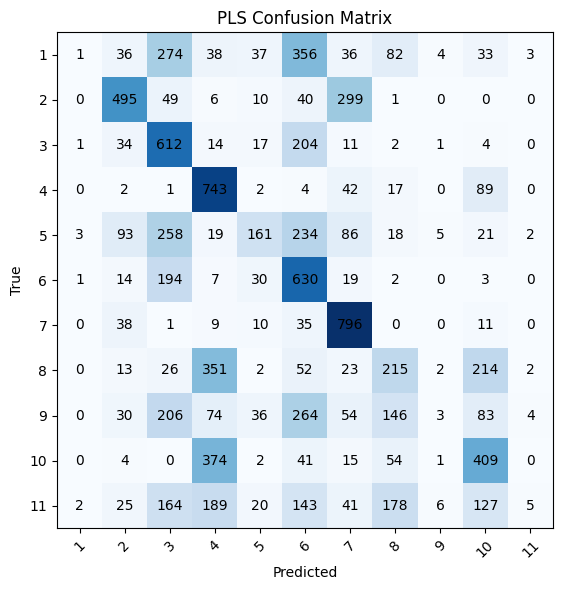


=== FINAL TEST PERFORMANCE: LDA ===
Accuracy:  0.5076
Precision: 0.5046
Recall:    0.5076
              precision    recall  f1-score   support

           1       0.27      0.19      0.22       900
           2       0.81      0.60      0.69       900
           3       0.60      0.63      0.61       900
           4       0.67      0.72      0.70       900
           5       0.39      0.50      0.44       900
           6       0.53      0.65      0.58       900
           7       0.71      0.73      0.72       900
           8       0.45      0.42      0.44       900
           9       0.29      0.25      0.27       900
          10       0.52      0.57      0.54       900
          11       0.33      0.32      0.32       900

    accuracy                           0.51      9900
   macro avg       0.50      0.51      0.50      9900
weighted avg       0.50      0.51      0.50      9900



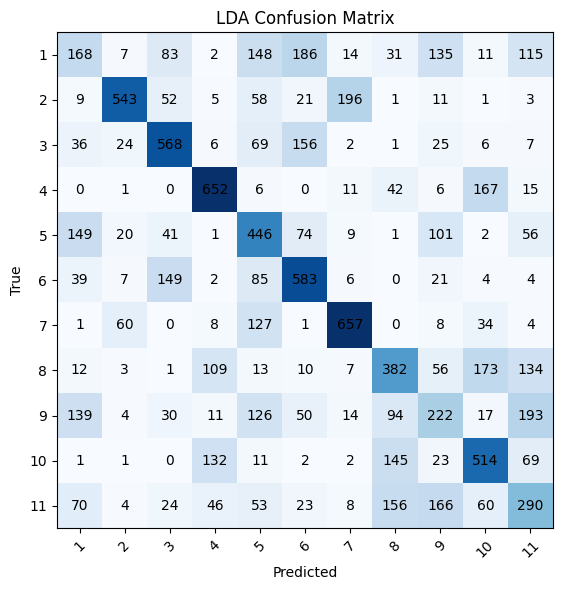

In [57]:
# --- Tune threshold and PLS components using validation set ---
rng = np.random.default_rng(42)  # fixed seed for reproducibility
MONTE_CARLO_SEEDS = rng.integers(low=0, high=10**6, size=1).tolist() # change size here to run over multiple seeds
thresholds = [60, 70, 80, 90]

mc_tuning_results = []
mc_best_choices = []

results_summary = []
cm_store_pls = {}
cm_store_lda = {}

for mc_seed in MONTE_CARLO_SEEDS:
    print("\n" + "#" * 80)
    print(f"MONTE CARLO RUN | seed = {mc_seed}")
    print("#" * 80)

    tuning_results = []
    tuning_results = []

    cm_store_pls_val = {}
    cm_store_lda_val = {}

    for thresh in thresholds:
        print("\n" + "=" * 70)
        print(f"TUNING THRESHOLD = {thresh} | seed = {mc_seed}")
        print("=" * 70)

        # Build train and validation data
        X_list_tr, y_img_tr, img_id_tr = build_or_load_cache(
            train_files,
            thresh=thresh,
            cache_path=make_train_core_cache_path(thresh, mc_seed),
            seed_base=mc_seed,
            dataset_tag="train_core"
        )

        X_list_va, y_img_va, img_id_va = build_or_load_cache(
            val_files,
            thresh=thresh,
            cache_path=make_val_cache_path(thresh, mc_seed),
            seed_base=mc_seed + 12345,
            dataset_tag="validation"
        )

        train_img_indices = np.arange(len(X_list_tr), dtype=int)
        val_img_indices   = np.arange(len(X_list_va), dtype=int)

        X_train, y_train, g_train = expand_images_to_pixels(X_list_tr, y_img_tr, img_id_tr, train_img_indices)
        X_val,   y_val,   g_val   = expand_images_to_pixels(X_list_va, y_img_va, img_id_va, val_img_indices)

        print("X_train:", X_train.shape, "| y_train:", y_train.shape, "| unique train images:", len(np.unique(g_train)))
        print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape,   "| unique val images:  ", len(np.unique(g_val)))

        # Tune n_components using train set
        pls_results = []
        for ncomp in range(1, 24, 2):
            mean_acc, std_acc = group_cv_accuracy_plsda(
                X_train, y_train, g_train,
                n_components=ncomp,
                n_splits=N_SPLITS
            )
            pls_results.append((ncomp, mean_acc, std_acc))
            print(f"n_components={ncomp:2d} | CV accuracy={mean_acc:.4f} ± {std_acc:.4f}")

        best_ncomp, best_mean, best_std = max(pls_results, key=lambda x: x[1])

        print("\nBest PLS-DA components:", best_ncomp)
        print(f"Best CV accuracy on train_core: {best_mean:.4f} ± {best_std:.4f}")

        # Fit final PLS on Train set, evaluate on validation
        scaler_final = StandardScaler()
        X_train_proc = scaler_final.fit_transform(X_train)
        X_val_proc   = scaler_final.transform(X_val)

        lb_pls = LabelBinarizer()
        Y_train_bin = lb_pls.fit_transform(y_train)
        classes_pls = lb_pls.classes_

        final_plsda = PLSRegression(n_components=best_ncomp)
        final_plsda.fit(X_train_proc, Y_train_bin)

        Y_val_pred = final_plsda.predict(X_val_proc)
        y_val_pred_pls = classes_pls[np.argmax(Y_val_pred, axis=1)]

        acc_pls = accuracy_score(y_val, y_val_pred_pls)
        prec_pls = precision_score(y_val, y_val_pred_pls, average='weighted', zero_division=0)
        rec_pls = recall_score(y_val, y_val_pred_pls, average='weighted', zero_division=0)

        cm_pls = confusion_matrix(y_val, y_val_pred_pls, labels=np.unique(y_train))

        # Fit final LDA on Train set, evaluate on validation
        lda_model = LinearDiscriminantAnalysis()
        lda_model.fit(X_train_proc, y_train)

        y_val_pred_lda = lda_model.predict(X_val_proc)

        acc_lda = accuracy_score(y_val, y_val_pred_lda)
        prec_lda = precision_score(y_val, y_val_pred_lda, average='weighted', zero_division=0)
        rec_lda = recall_score(y_val, y_val_pred_lda, average='weighted', zero_division=0)

        cm_lda = confusion_matrix(y_val, y_val_pred_lda, labels=np.unique(y_train))

        print("\n=== VALIDATION PERFORMANCE ===")
        print(f"PLS-DA | acc={acc_pls:.4f} | prec={prec_pls:.4f} | rec={rec_pls:.4f}")
        print(f"LDA    | acc={acc_lda:.4f} | prec={prec_lda:.4f} | rec={rec_lda:.4f}")

        tuning_results.append({
            "threshold": thresh,
            "best_ncomp": best_ncomp,
            "pls_val_acc": acc_pls,
            "pls_val_prec": prec_pls,
            "pls_val_rec": rec_pls,
            "lda_val_acc": acc_lda,
            "lda_val_prec": prec_lda,
            "lda_val_rec": rec_lda,
        })

        cm_store_pls_val[thresh] = cm_pls
        cm_store_lda_val[thresh] = cm_lda

    tuning_results_df = pd.DataFrame(tuning_results).sort_values("threshold")
    display(tuning_results_df)

    best_row = tuning_results_df.loc[tuning_results_df["pls_val_acc"].idxmax()]
    BEST_THRESHOLD = int(best_row["threshold"])
    BEST_NCOMP = int(best_row["best_ncomp"])

    print("Chosen threshold from validation:", BEST_THRESHOLD)
    print("Chosen n_components from validation:", BEST_NCOMP)

    # --- Final fit on full training set, final evaluation on test set ---
    X_list_full, y_img_full, img_id_full = build_or_load_cache(
        all_train_files,
        thresh=BEST_THRESHOLD,
        cache_path=make_fulltrain_cache_path(BEST_THRESHOLD, mc_seed),
        seed_base=RANDOM_SEED,
        dataset_tag="full_train"
    )

    X_list_te, y_img_te, img_id_te = build_or_load_cache(
        test_files,
        thresh=BEST_THRESHOLD,
        cache_path=make_test_cache_path(BEST_THRESHOLD, mc_seed),
        seed_base=RANDOM_SEED + 54321,
        dataset_tag="test"
    )

    full_img_indices = np.arange(len(X_list_full), dtype=int)
    test_img_indices = np.arange(len(X_list_te), dtype=int)

    X_full, y_full, g_full = expand_images_to_pixels(X_list_full, y_img_full, img_id_full, full_img_indices)
    X_test, y_test, g_test = expand_images_to_pixels(X_list_te, y_img_te, img_id_te, test_img_indices)

    # PLS final
    scaler_final = StandardScaler()
    X_full_proc = scaler_final.fit_transform(X_full)
    X_test_proc = scaler_final.transform(X_test)

    lb_pls = LabelBinarizer()
    Y_full_bin = lb_pls.fit_transform(y_full)
    classes_pls = lb_pls.classes_

    final_plsda = PLSRegression(n_components=BEST_NCOMP)
    final_plsda.fit(X_full_proc, Y_full_bin)

    Y_test_pred = final_plsda.predict(X_test_proc)
    y_test_pred_pls = classes_pls[np.argmax(Y_test_pred, axis=1)]  

    acc_pls = accuracy_score(y_test, y_test_pred_pls)
    prec_pls = precision_score(y_test, y_test_pred_pls, average='weighted', zero_division=0)
    rec_pls = recall_score(y_test, y_test_pred_pls, average='weighted', zero_division=0)
    
    print("\n=== FINAL TEST PERFORMANCE: PLS-DA ===")
    print(f"Accuracy:  {acc_pls:.4f}")
    print(f"Precision: {prec_pls:.4f}")
    print(f"Recall:    {rec_pls:.4f}")
    print(classification_report(y_test, y_test_pred_pls, digits=4, zero_division=0))

    cm_pls = confusion_matrix(y_test, y_test_pred_pls, labels=np.unique(y_train))

    plt.figure(figsize=(8, 6))
    plt.imshow(cm_pls, cmap="Blues")
    plt.title("PLS Confusion Matrix")
    plt.xticks(range(len(np.unique(y_train))), np.unique(y_train), rotation=45)
    plt.yticks(range(len(np.unique(y_train))), np.unique(y_train))
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm_pls.shape[0]):
        for j in range(cm_pls.shape[1]):
            plt.text(j, i, cm_pls[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

    # LDA final
    lda_model = LinearDiscriminantAnalysis()
    lda_model.fit(X_full_proc, y_full)
    y_test_pred_lda = lda_model.predict(X_test_proc)

    acc_lda = accuracy_score(y_test, y_test_pred_lda)
    prec_lda = precision_score(y_test, y_test_pred_lda, average='weighted', zero_division=0)
    rec_lda =recall_score(y_test, y_test_pred_lda, average='weighted', zero_division=0)

    print("\n=== FINAL TEST PERFORMANCE: LDA ===")
    print(f"Accuracy:  {acc_lda:.4f}")
    print(f"Precision: {prec_lda:.4f}")
    print(f"Recall:    {rec_lda:.4f}")
    print(classification_report(y_test, y_test_pred_lda))

    cm_lda = confusion_matrix(y_test, y_test_pred_lda, labels=np.unique(y_train))

    plt.figure(figsize=(8, 6))
    plt.imshow(cm_lda, cmap="Blues")
    plt.title("LDA Confusion Matrix")
    plt.xticks(range(len(np.unique(y_train))), np.unique(y_train), rotation=45)
    plt.yticks(range(len(np.unique(y_train))), np.unique(y_train))
    plt.xlabel("Predicted")
    plt.ylabel("True")

    for i in range(cm_lda.shape[0]):
        for j in range(cm_lda.shape[1]):
            plt.text(j, i, cm_lda[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()  

    results_summary.append({
        "seed": mc_seed,
        "threshold": thresh,
        "pls_accuracy": acc_pls,
        "pls_precision": prec_pls,
        "pls_recall": rec_pls,
        "lda_accuracy": acc_lda,
        "lda_precision": prec_lda,
        "lda_recall": rec_lda,
        "best_ncomp": BEST_NCOMP
    })

    cm_store_pls[mc_seed] = cm_pls
    cm_store_lda[mc_seed] = cm_lda



,seed,threshold,pls_accuracy,pls_precision,pls_recall,lda_accuracy,lda_precision,lda_recall,best_ncomp
0,89250,90,0.411111,0.366752,0.411111,0.507576,0.504619,0.507576,15


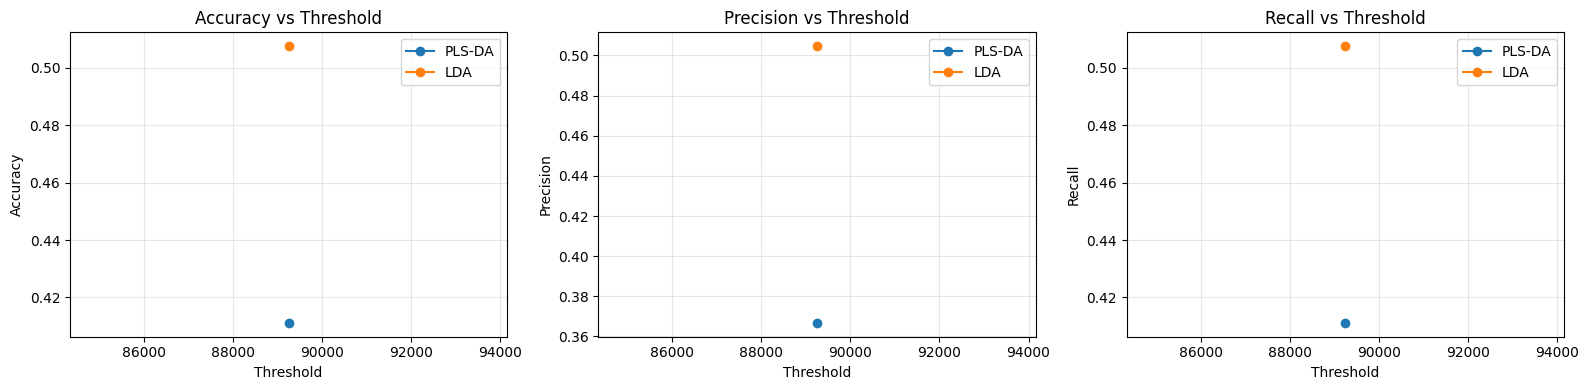

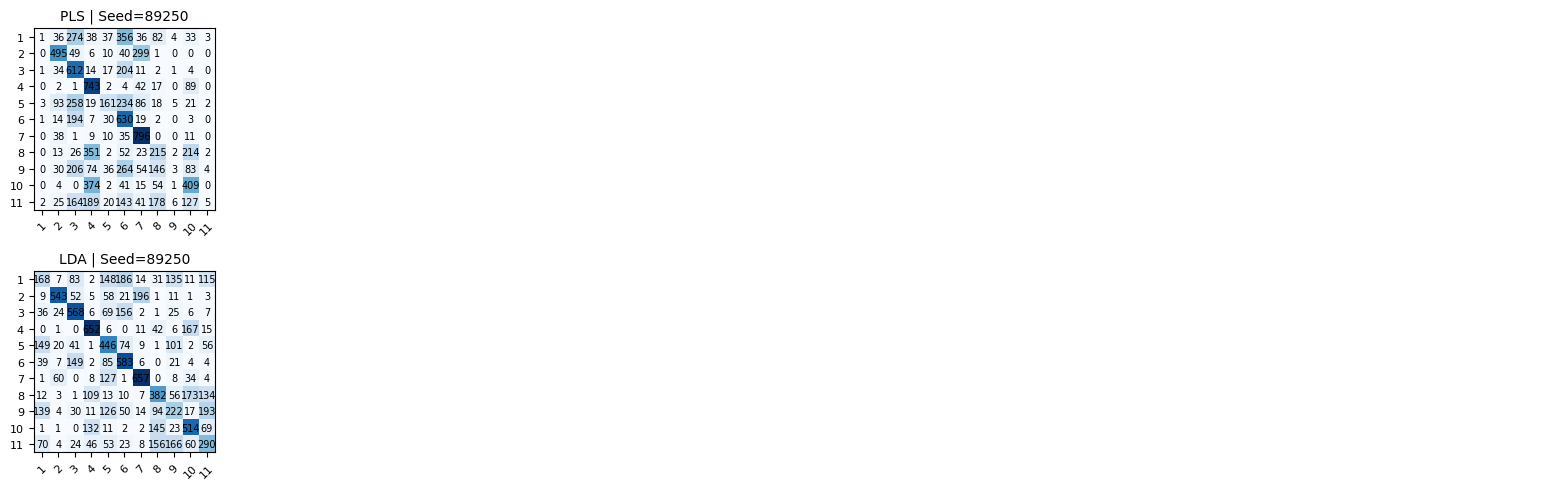

In [58]:
results_df = pd.DataFrame(results_summary).sort_values("threshold")
display(results_df)

# Metric line plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

# Accuracy
axes[0].plot(results_df["seed"], results_df["pls_accuracy"], marker="o", label="PLS-DA")
axes[0].plot(results_df["seed"], results_df["lda_accuracy"], marker="o", label="LDA")
axes[0].set_title("Accuracy vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Precision
axes[1].plot(results_df["seed"], results_df["pls_precision"], marker="o", label="PLS-DA")
axes[1].plot(results_df["seed"], results_df["lda_precision"], marker="o", label="LDA")
axes[1].set_title("Precision vs Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Precision")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Recall
axes[2].plot(results_df["seed"], results_df["pls_recall"], marker="o", label="PLS-DA")
axes[2].plot(results_df["seed"], results_df["lda_recall"], marker="o", label="LDA")
axes[2].set_title("Recall vs Threshold")
axes[2].set_xlabel("Threshold")
axes[2].set_ylabel("Recall")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# Confusion matrices
seeds_sorted = sorted(cm_store_pls.keys())
labels = np.unique(y_train)

n_seeds = len(seeds_sorted)
n_groups = int(np.ceil(n_seeds / 2))

# Each group = 2 rows → total rows = 2 * n_groups
fig, axes = plt.subplots(2 * n_groups, 2, figsize=(20, 5 * n_groups))
axes = np.array(axes)

for g in range(n_groups):
    seed_idx_1 = 2 * g
    seed_idx_2 = 2 * g + 1

    row_pls = 2 * g
    row_lda = 2 * g + 1

    # PLS-DA
    for col, seed_idx in enumerate([seed_idx_1, seed_idx_2]):
        ax = axes[row_pls, col]

        if seed_idx < n_seeds:
            seed = seeds_sorted[seed_idx]
            cm = cm_store_pls[seed]

            ax.imshow(cm, cmap="Blues")
            ax.set_title(f"PLS | Seed={seed}", fontsize=10)

            ax.set_xticks(range(len(labels)))
            ax.set_yticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=45, fontsize=8)
            ax.set_yticklabels(labels, fontsize=8)

            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7)
        else:
            ax.axis("off")

    # LDA 
    for col, seed_idx in enumerate([seed_idx_1, seed_idx_2]):
        ax = axes[row_lda, col]

        if seed_idx < n_seeds:
            seed = seeds_sorted[seed_idx]
            cm = cm_store_lda[seed]

            ax.imshow(cm, cmap="Blues")
            ax.set_title(f"LDA | Seed={seed}", fontsize=10)

            ax.set_xticks(range(len(labels)))
            ax.set_yticks(range(len(labels)))
            ax.set_xticklabels(labels, rotation=45, fontsize=8)
            ax.set_yticklabels(labels, fontsize=8)

            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7)
        else:
            ax.axis("off")

plt.tight_layout()
plt.show()